In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("D:/Projects/Customer_Churn/data/telco_churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
pd.to_numeric(df["TotalCharges"],errors="coerce").isna().sum()

np.int64(11)

In [8]:
df.loc[pd.to_numeric(df["TotalCharges"],errors = "coerce").isna(), ["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [12]:
df.loc[df["TotalCharges"].isna(),["tenure","MonthlyCharges","TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [14]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["customerID"].duplicated().sum()

np.int64(0)

In [17]:
for col in df.select_dtypes(include = "str").columns:
    print(f"{col}:{df[col].nunique()} unique values")

    if df[col].nunique()<20:
        print(df[col].unique())
    print("\n")

    



customerID:7043 unique values


gender:2 unique values
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


Partner:2 unique values
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Dependents:2 unique values
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


PhoneService:2 unique values
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


MultipleLines:3 unique values
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str


InternetService:3 unique values
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


OnlineSecurity:3 unique values
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


OnlineBackup:3 unique values
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str


DeviceProtection:3 unique values
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


TechSupport:3 unique values
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


StreamingTV:3 unique values
<S

In [18]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [20]:
df.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [21]:
df[["tenure","MonthlyCharges","TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


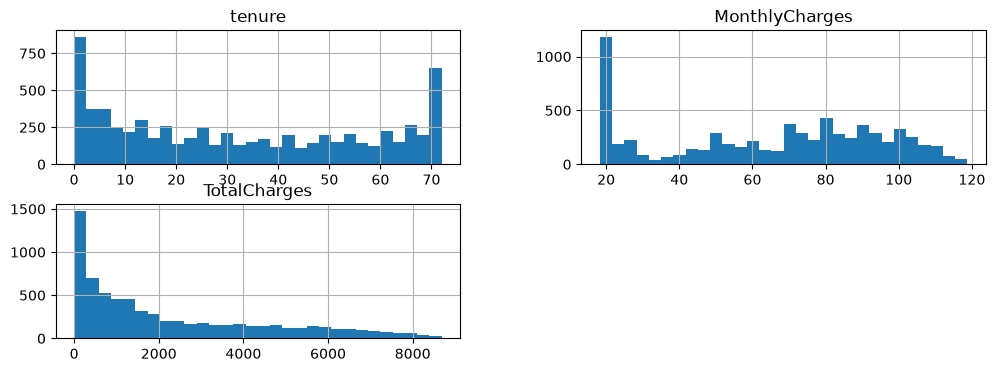

In [22]:
df[["tenure","MonthlyCharges","TotalCharges"]].hist(
    bins = 30,
    figsize = (12,4)
)

plt.tight_layout
plt.show()

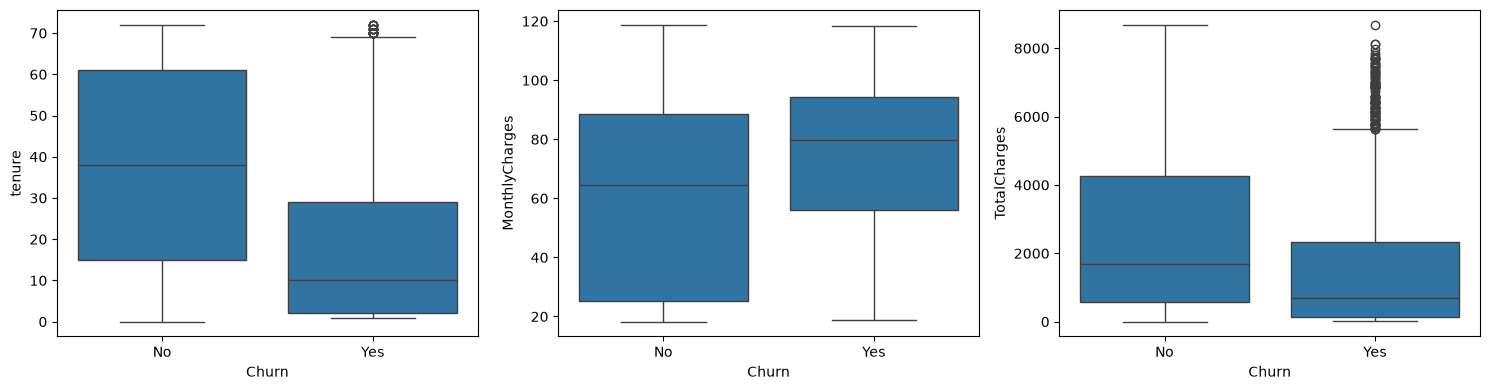

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[2])

plt.tight_layout()
plt.show()

In [24]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize = "index"

) *100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


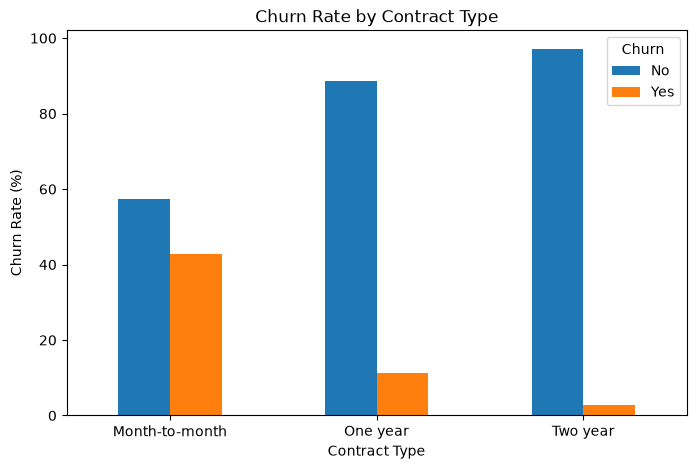

In [25]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.show()

In [26]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col not in ["customerID", "Churn"]:
        churn_rate = pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        )["Yes"] * 100
        
        print(f"\n{col}")
        print(churn_rate.sort_values(ascending=False))


gender
gender
Female    26.920872
Male      26.160338
Name: Yes, dtype: float64

Partner
Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

Dependents
Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64

PhoneService
PhoneService
Yes    26.709637
No     24.926686
Name: Yes, dtype: float64

MultipleLines
MultipleLines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Yes, dtype: float64

InternetService
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64

OnlineBackup
OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Yes, dtype: float64

DeviceProtection
DeviceProtection
No                     39.127625
Yes              

C:\Users\sushil\AppData\Local\Temp\ipykernel_14280\3829233130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


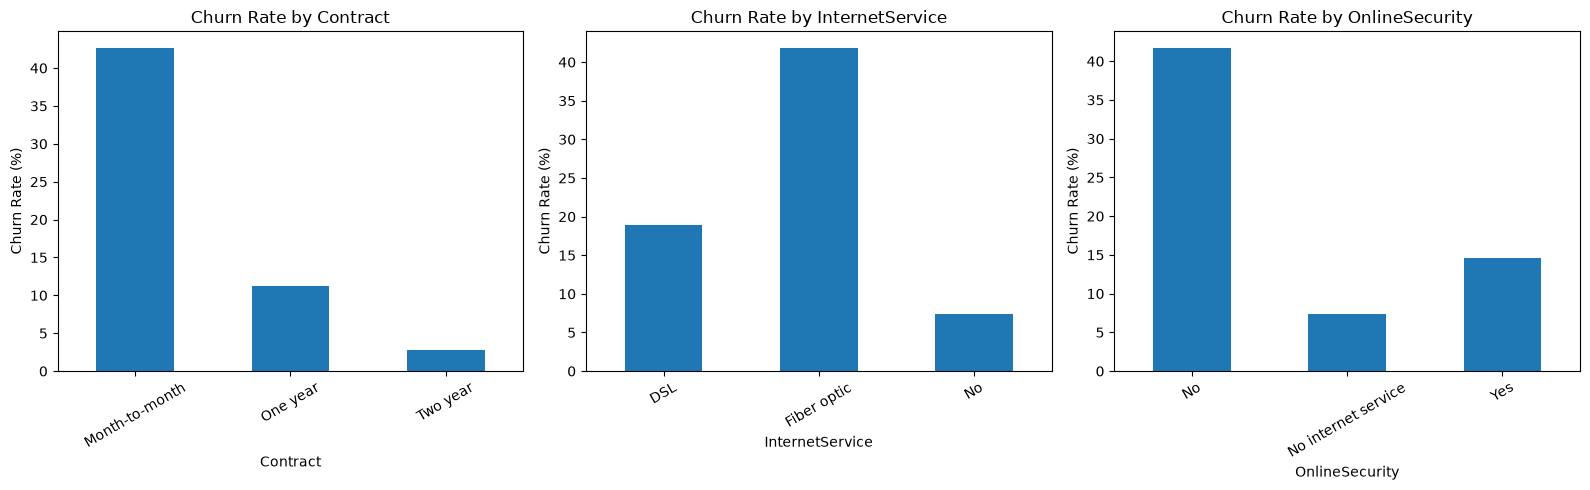

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ["Contract", "InternetService", "OnlineSecurity"]

for ax, col in zip(axes, features):
    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
    
    churn_rate.plot(kind="bar", ax=ax)
    
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [28]:
def plot_churn_rate(df, features, ncols=3):
    nrows = (len(features) + ncols - 1) // ncols
    
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 5 * nrows)
    )
    
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, features):
        churn_rate = (
            pd.crosstab(
                df[col],
                df["Churn"],
                normalize="index"
            )["Yes"] * 100
        )

        churn_rate.plot(kind="bar", ax=ax)

        ax.set_title(f"Churn Rate by {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Churn Rate (%)")
        ax.tick_params(axis="x", rotation=20)

    for ax in axes[len(features):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

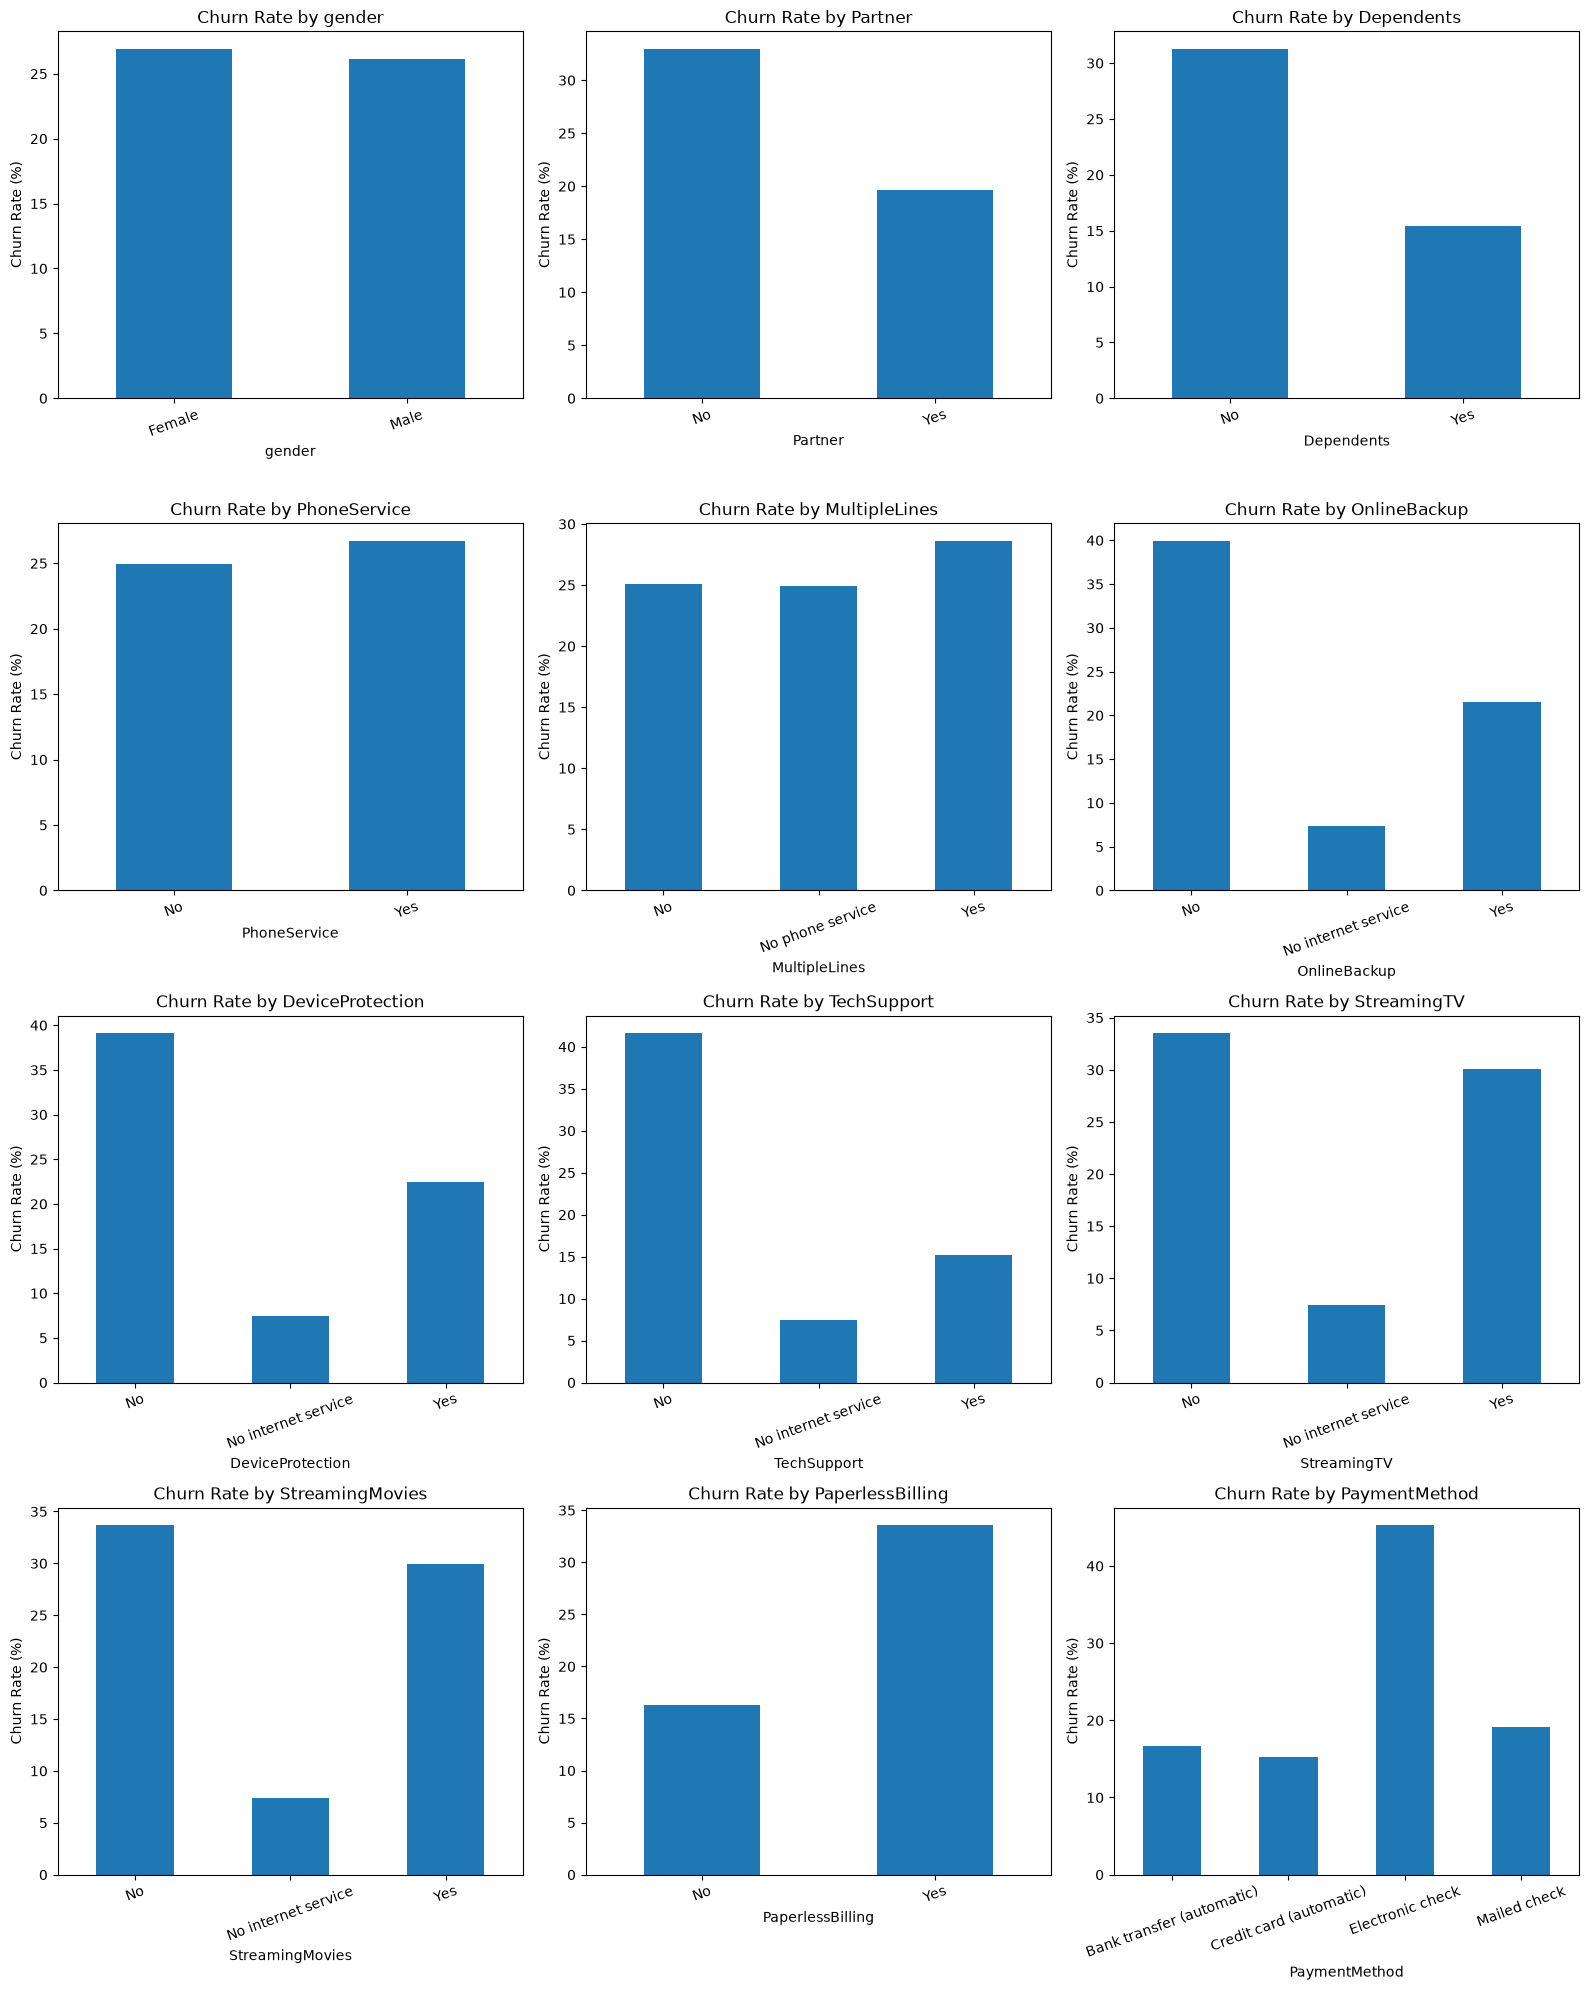

In [29]:
features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "PaymentMethod"
]

plot_churn_rate(df, features)

In [30]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


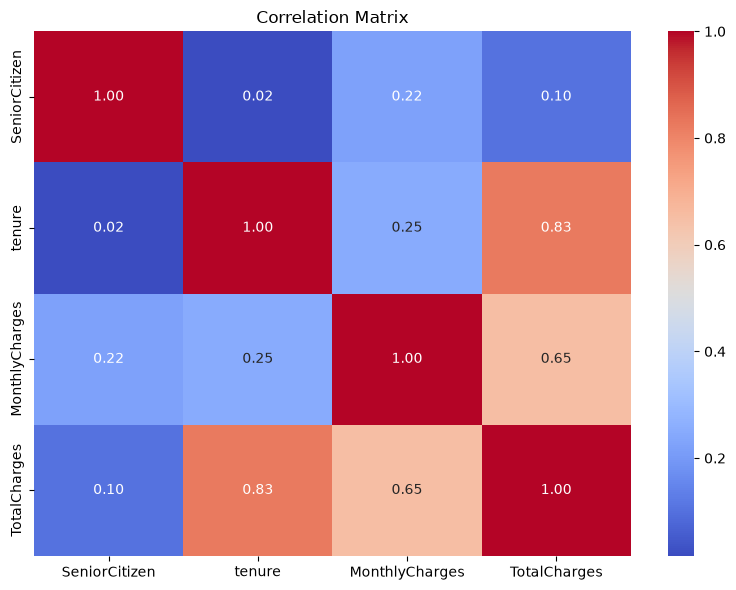

In [31]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [32]:
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower bound: -46.02499999999999
Upper bound: 171.375


In [33]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} potential outliers")

tenure: 0 potential outliers
MonthlyCharges: 0 potential outliers
TotalCharges: 0 potential outliers


In [35]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print()

tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0

MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994

TotalCharges
Q1: 398.55
Q3: 3786.6
IQR: 3388.0499999999997



In [37]:
important_features = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling"
]

for col in important_features:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        )["Yes"].mul(100).round(2)
    )


--- Contract ---
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

--- InternetService ---
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Yes, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Yes, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Yes, dtype: float64

--- DeviceProtection ---
DeviceProtection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: Yes, dtype: float64

--- TechSupport ---
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Yes, dtype: float64

--- PaymentMethod ---
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
M

In [38]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
TenureGroup,,
0-6,47.06,52.94
7-12,64.11,35.89
13-24,71.29,28.71
25-48,79.61,20.39
49-72,90.49,9.51


In [39]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TenureGroup']

### Feature Engineering

In [40]:
df_model = df.copy()

In [41]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [42]:
df_model["TotalServices"] = (
    df_model[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

In [43]:
df_model["IsNewCustomer"] = (
    df_model["tenure"] <= 6
).astype(int)

In [44]:
df_model["LongTermContract"] = (
    df_model["Contract"].isin(["One year", "Two year"])
).astype(int)

In [45]:
df_model["AvgMonthlySpend"] = (
    df_model["TotalCharges"] /
    df_model["tenure"].replace(0, np.nan)
)

In [46]:
df_model["AvgMonthlySpend"] = (
    df_model["AvgMonthlySpend"]
    .fillna(df_model["MonthlyCharges"])
)

In [47]:
df_model["HasSupport"] = (
    df_model["TechSupport"] == "Yes"
).astype(int)

In [48]:
df_model["HasSecurity"] = (
    df_model["OnlineSecurity"] == "Yes"
).astype(int)

In [49]:
df_model["ChargePerTenureMonth"] = (
    df_model["TotalCharges"] /
    df_model["tenure"].replace(0, np.nan)
)

In [50]:
df_model["ChargePerTenureMonth"] = (
    df_model["ChargePerTenureMonth"]
    .fillna(df_model["MonthlyCharges"])
)

In [51]:
engineered_features = [
    "TotalServices",
    "IsNewCustomer",
    "LongTermContract",
    "AvgMonthlySpend",
    "HasSupport",
    "HasSecurity",
    "ChargePerTenureMonth"
]

df_model[engineered_features].head()

,TotalServices,IsNewCustomer,LongTermContract,AvgMonthlySpend,HasSupport,HasSecurity,ChargePerTenureMonth
0,1,1,0,29.850000,0,0,29.850000
1,3,0,1,55.573529,0,1,55.573529
2,3,1,0,54.075000,0,1,54.075000
3,3,0,1,40.905556,1,1,40.905556
4,1,1,0,75.825000,0,0,75.825000


In [52]:
df_model[engineered_features].describe()

,TotalServices,IsNewCustomer,LongTermContract,AvgMonthlySpend,HasSupport,HasSecurity,ChargePerTenureMonth
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,3.362914,0.210280,0.449808,64.762906,0.290217,0.286668,64.762906
std,2.062031,0.407536,0.497510,30.189796,0.453895,0.452237,30.189796
min,0.000000,0.000000,0.000000,13.775000,0.000000,0.000000,13.775000
25%,1.000000,0.000000,0.000000,35.935156,0.000000,0.000000,35.935156
50%,3.000000,0.000000,0.000000,70.337500,0.000000,0.000000,70.337500
75%,5.000000,0.000000,1.000000,90.174158,1.000000,1.000000,90.174158
max,8.000000,1.000000,1.000000,121.400000,1.000000,1.000000,121.400000


In [53]:
print("Missing values:")
print(df_model[engineered_features].isna().sum())

print("\nInfinite values:")
print(
    np.isinf(
        df_model[engineered_features]
        .select_dtypes(include=np.number)
    ).sum()
)

Missing values:
TotalServices           0
IsNewCustomer           0
LongTermContract        0
AvgMonthlySpend         0
HasSupport              0
HasSecurity             0
ChargePerTenureMonth    0
dtype: int64

Infinite values:
TotalServices           0
IsNewCustomer           0
LongTermContract        0
AvgMonthlySpend         0
HasSupport              0
HasSecurity             0
ChargePerTenureMonth    0
dtype: int64


In [54]:
pd.crosstab(
    df_model["TotalServices"],
    df_model["Churn"],
    normalize="index"
)["Yes"].mul(100).round(2)

TotalServices
0    43.75
1    21.11
2    32.83
3    36.48
4    31.34
5    25.55
6    22.49
7    12.41
8     5.29
Name: Yes, dtype: float64

In [55]:
pd.crosstab(
    df_model["IsNewCustomer"],
    df_model["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
IsNewCustomer,,
0,80.49,19.51
1,47.06,52.94


In [56]:
df_model[
    numeric_cols + engineered_features
].corr()

,tenure,MonthlyCharges,TotalCharges,TotalServices,IsNewCustomer,LongTermContract,AvgMonthlySpend,HasSupport,HasSecurity,ChargePerTenureMonth
tenure,1.000000,0.247900,0.826178,0.523600,-0.627442,0.645561,0.247234,0.324221,0.327203,0.247234
MonthlyCharges,0.247900,1.000000,0.651174,0.802322,-0.171897,-0.060165,0.996244,0.338304,0.296594,0.996244
TotalCharges,0.826178,0.651174,1.000000,0.795854,-0.486540,0.444255,0.651025,0.431883,0.411651,0.651025
TotalServices,0.523600,0.802322,0.795854,1.000000,-0.351903,0.282007,0.800366,0.584471,0.522362,0.800366
IsNewCustomer,-0.627442,-0.171897,-0.486540,-0.351903,1.000000,-0.418946,-0.171431,-0.207130,-0.214626,-0.171431
LongTermContract,0.645561,-0.060165,0.444255,0.282007,-0.418946,1.000000,-0.059102,0.285241,0.246679,-0.059102
AvgMonthlySpend,0.247234,0.996244,0.651025,0.800366,-0.171431,-0.059102,1.000000,0.338045,0.296915,1.000000
HasSupport,0.324221,0.338304,0.431883,0.584471,-0.207130,0.285241,0.338045,1.000000,0.354931,0.338045
HasSecurity,0.327203,0.296594,0.411651,0.522362,-0.214626,0.246679,0.296915,0.354931,1.000000,0.296915
ChargePerTenureMonth,0.247234,0.996244,0.651025,0.800366,-0.171431,-0.059102,1.000000,0.338045,0.296915,1.000000
